In [1]:
import torch
import pandas as pd
import numpy as np
from dataset import ADNI_tabular
from models.nmm import NMM
from utils.directory_navigator import DirectoryNavigator

N_RT = 20
N_RV = 3
N_RI = 3
root = './'
model_width = 128
model_depth = 3
num_classes = 3
dropout_rate = 0
output_path = 'latent_representations.csv'

# Fixed — do not change
model_name = 'NMM'
is_multi = True
fixed_followup_year = 0
num_of_tabular_features = 114
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
root_splits = root + 'splits/'

print(f"Using device: {device}")

Using device: cuda


In [14]:
def extract_hidden_features(loader, network, device):
    activations = {}

    def hook_fn(module, input, output):
        activations['hidden'] = input[0].detach().cpu().numpy()

    target_layer = dict(network.named_modules())['layers.10']
    handle = target_layer.register_forward_hook(hook_fn)

    network.eval()
    with torch.no_grad():
        for batch in loader:
            features = batch['Features'].to(device)
            missingness_mask = batch['MissingnessMask'].to(device)
            delta_t = batch['delta_t'].to(device)
            _ = network(features, missingness_mask, delta_t)

    handle.remove()
    return activations['hidden']

def extract_hidden_features_from_batch(batch, network, device):
    activations = {}

    def hook_fn(module, input, output):
        activations['hidden'] = input[0].detach().cpu().numpy()

    target_layer = dict(network.named_modules())['layers.10']
    handle = target_layer.register_forward_hook(hook_fn)

    network.eval()
    with torch.no_grad():
        features         = batch['Features'].to(device)
        missingness_mask = batch['MissingnessMask'].to(device)
        delta_t          = batch['delta_t'].to(device)
        _                = network(features, missingness_mask, delta_t)

    handle.remove()
    return activations['hidden']


def get_baseline_loader(i_rt, i_rv, dir_navi):
    dataset = ADNI_tabular(
        trainvaltest='Test',
        is_multi=is_multi,
        fixed_followup_year=fixed_followup_year,
        data_dir=dir_navi.get_data_dir(i_rt, i_rv=i_rv)
    )
    return torch.utils.data.DataLoader(dataset, batch_size=len(dataset), shuffle=False)

In [3]:
sample_batch = next(iter(loader))
print(type(sample_batch))
print(sample_batch.keys() if isinstance(sample_batch, dict) else [x.shape for x in sample_batch])

NameError: name 'loader' is not defined

In [4]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

dir_navi = DirectoryNavigator(root_splits, model_name, is_multi, fixed_followup_year)

network = NMM(
    input_size=num_of_tabular_features,
    model_width=model_width,
    model_depth=model_depth,
    dropout_rate=dropout_rate,
    num_classes=num_classes
).to(device)

patient_sum = {}
patient_count = {}

for i_rt in range(N_RT):
    print(f"Processing train/test split {i_rt}...")

    for i_rv in range(N_RV):
        loader = get_baseline_loader(i_rt, i_rv, dir_navi)

        for i_ri in range(N_RI):
            weights_path = dir_navi.get_training_results_dir(i_rt, i_rv, i_ri) + 'model_weights.pt'
            network.load_state_dict(torch.load(weights_path, map_location=device))
            network.eval()

            # Pull RIDs from the batch directly — guaranteed to align with features
            batch = next(iter(loader))
            test_rids = batch['RID']

            features = extract_hidden_features(loader, network, device)

            for idx, rid in enumerate(test_rids):
                rid = rid.item() if hasattr(rid, 'item') else rid  # handle tensor RIDs
                if rid not in patient_sum:
                    patient_sum[rid] = features[idx].copy()
                    patient_count[rid] = 1
                else:
                    patient_sum[rid] += features[idx]
                    patient_count[rid] += 1

    print(f"Split {i_rt} complete.")

print("Extraction complete.")

rids = sorted(patient_sum.keys())
avg_features = np.stack([patient_sum[rid] / patient_count[rid] for rid in rids])

latent_df = pd.DataFrame({
    'RID': rids,
    'n_models_averaged': [patient_count[rid] for rid in rids],
    'latent': [avg_features[i] for i in range(len(rids))]
})

latent_df.to_csv(output_path, index=False)
print(f"Saved {latent_df.shape[0]} patient representations to {output_path}")
latent_df.head()

Processing train/test split 0...
Split 0 complete.
Processing train/test split 1...
Split 1 complete.
Processing train/test split 2...
Split 2 complete.
Processing train/test split 3...
Split 3 complete.
Processing train/test split 4...
Split 4 complete.
Processing train/test split 5...
Split 5 complete.
Processing train/test split 6...
Split 6 complete.
Processing train/test split 7...
Split 7 complete.
Processing train/test split 8...
Split 8 complete.
Processing train/test split 9...
Split 9 complete.
Processing train/test split 10...
Split 10 complete.
Processing train/test split 11...
Split 11 complete.
Processing train/test split 12...
Split 12 complete.
Processing train/test split 13...
Split 13 complete.
Processing train/test split 14...
Split 14 complete.
Processing train/test split 15...
Split 15 complete.
Processing train/test split 16...
Split 16 complete.
Processing train/test split 17...
Split 17 complete.
Processing train/test split 18...
Split 18 complete.
Processing tr

,RID,n_models_averaged,latent
0,4.0,90,"[0.9664966, 0.6035907, 0.0, 1.6294544, 0.26050..."
1,5.0,108,"[0.0, 7.9162164, 0.70680887, 2.6209528, 0.6787..."
2,6.0,81,"[1.6452168, 0.038957838, 0.0, 2.2310095, 0.497..."
3,14.0,135,"[0.0, 8.6908045, 0.78898674, 3.3127031, 0.6545..."
4,15.0,108,"[0.0, 13.575004, 1.4276845, 5.0754647, 1.01365..."


In [15]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

FOLLOWUP_YEARS = [1, 2, 3, 4, 5]   # mirrors the years present in the main df

dir_navi = DirectoryNavigator(root_splits, model_name, is_multi, fixed_followup_year)

network = NMM(
    input_size=num_of_tabular_features,
    model_width=model_width,
    model_depth=model_depth,
    dropout_rate=dropout_rate,
    num_classes=num_classes
).to(device)

visit_sum   = {}
visit_count = {}

for i_rt in range(N_RT):
    print(f"Processing train/test split {i_rt}...")
    for i_rv in range(N_RV):
        loader = get_baseline_loader(i_rt, i_rv, dir_navi)

        if len(loader.dataset) == 0:
            continue

        for i_ri in range(N_RI):
            weights_path = dir_navi.get_training_results_dir(i_rt, i_rv, i_ri) + 'model_weights.pt'
            network.load_state_dict(torch.load(weights_path, map_location=device))
            network.eval()

            batch     = next(iter(loader))
            test_rids = batch['RID']
            delta_ts  = batch['delta_t'].tolist()
            features  = extract_hidden_features_from_batch(batch, network, device)

            for idx, rid in enumerate(test_rids):
                rid = rid.item() if hasattr(rid, 'item') else rid
                delta_t = round(delta_ts[idx], 2)
                key = (rid, delta_t)
                if key not in visit_sum:
                    visit_sum[key]   = features[idx].copy()
                    visit_count[key] = 1
                else:
                    visit_sum[key]   += features[idx]
                    visit_count[key] += 1

    print(f"Split {i_rt} complete.")

print("Extraction complete.")

rows = []
for (rid, delta_t), vec_sum in visit_sum.items():
    rows.append({
        'RID':               rid,
        'delta_t':           delta_t,
        'n_models_averaged': visit_count[(rid, delta_t)],
        'latent':            vec_sum / visit_count[(rid, delta_t)],
    })

latent_visit_df = (pd.DataFrame(rows)
                   .sort_values(['RID', 'delta_t'])
                   .reset_index(drop=True))

print(f"Output: {len(latent_visit_df)} rows  "
      f"({latent_visit_df['RID'].nunique()} patients)")
print(f"Rows per patient sample:\n{latent_visit_df.groupby('RID').size().value_counts().sort_index()}")

latent_visit_df.to_csv('latent_representations_per_visit.csv', index=False)
latent_visit_df.head(10)

Processing train/test split 0...
Split 0 complete.
Processing train/test split 1...
Split 1 complete.
Processing train/test split 2...
Split 2 complete.
Processing train/test split 3...
Split 3 complete.
Processing train/test split 4...
Split 4 complete.
Processing train/test split 5...
Split 5 complete.
Processing train/test split 6...
Split 6 complete.
Processing train/test split 7...
Split 7 complete.
Processing train/test split 8...
Split 8 complete.
Processing train/test split 9...
Split 9 complete.
Processing train/test split 10...
Split 10 complete.
Processing train/test split 11...
Split 11 complete.
Processing train/test split 12...
Split 12 complete.
Processing train/test split 13...
Split 13 complete.
Processing train/test split 14...
Split 14 complete.
Processing train/test split 15...
Split 15 complete.
Processing train/test split 16...
Split 16 complete.
Processing train/test split 17...
Split 17 complete.
Processing train/test split 18...
Split 18 complete.
Processing tr

,RID,delta_t,n_models_averaged,latent
0,4.0,12.16,45,"[0.74215037, 0.82436275, 0.0, 1.4536177, 0.262..."
1,4.0,36.26,45,"[1.1908427, 0.38281855, 0.0, 1.8052909, 0.2587..."
2,5.0,11.90,36,"[0.0, 9.028442, 0.85610384, 3.1630363, 0.73361..."
3,5.0,23.93,36,"[0.0, 7.737342, 0.6893183, 2.5594785, 0.662381..."
4,5.0,36.03,36,"[0.0, 6.9828615, 0.57500446, 2.140343, 0.64038..."
5,6.0,11.67,27,"[1.4434694, 0.09301914, 0.0, 1.9782312, 0.3202..."
6,6.0,23.25,27,"[1.6515687, 0.023854366, 0.0, 2.2336977, 0.507..."
7,6.0,36.23,27,"[1.840612, 0.0, 0.0, 2.4810994, 0.66602224, 0...."
8,14.0,12.72,45,"[0.0, 9.5933075, 0.9071047, 3.9376109, 0.65889..."
9,14.0,24.69,45,"[0.0, 8.598741, 0.7801432, 3.2800324, 0.648097..."


In [17]:
latent_visit_df['latent'][0]==latent_visit_df['latent'][1]

array([False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False,  True, False, False, False,
       False, False, False, False, False])

Fitting t-SNE...


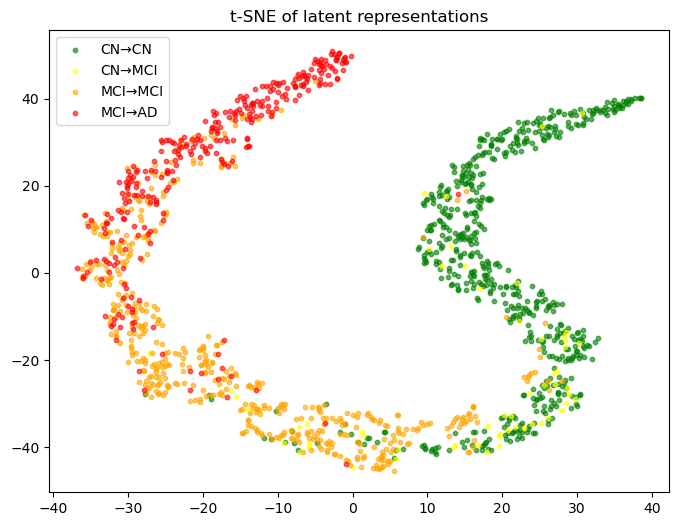

0
PlotLabel
CN→CN      583
MCI→MCI    510
MCI→AD     300
CN→MCI      59
Name: count, dtype: int64


In [11]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Get the last non-null follow-up diagnosis as endpoint

full_df = pd.read_csv(root + 'preprocessing_outputs/step3.csv')
fdx_cols = ['FDX_0', 'FDX_1', 'FDX_2', 'FDX_3', 'FDX_4', 'FDX_5']
meta_df = full_df[['RID', 'DX'] + fdx_cols].drop_duplicates(subset='RID').copy()
meta_df['EndpointDX'] = meta_df[fdx_cols].ffill(axis=1).iloc[:, -1]

def get_colour_label(row):
    if row['DX'] == 'CN' and row['EndpointDX'] == 'CN':
        return 'CN→CN'
    elif row['DX'] == 'CN' and row['EndpointDX'] == 'MCI':
        return 'CN→MCI'
    elif row['DX'] == 'MCI' and row['EndpointDX'] == 'MCI':
        return 'MCI→MCI'
    elif row['DX'] == 'MCI' and row['EndpointDX'] == 'Dementia':
        return 'MCI→AD'

colour_map = {
    'CN→CN':   'green',
    'CN→MCI':  'yellow',
    'MCI→MCI': 'orange',
    'MCI→AD':  'red',
}

meta_df['PlotLabel'] = meta_df.apply(get_colour_label, axis=1)
plot_df = latent_df.merge(meta_df[['RID', 'PlotLabel']], on='RID', how='left')
latent_matrix = np.stack(plot_df['latent'].values)

def plot_embedding(coords, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    for label, colour in colour_map.items():
        mask = plot_df['PlotLabel'] == label
        ax.scatter(coords[mask, 0], coords[mask, 1], c=colour, label=label, alpha=0.6, s=10)
    ax.set_title(title)
    ax.legend()
    plt.savefig('t_sne.png', dpi=300, bbox_inches='tight')
    plt.show()

# t-SNE
print("Fitting t-SNE...")
tsne = TSNE(n_components=2, random_state=42, init='pca', perplexity=30, n_jobs=-1)
tsne_coords = tsne.fit_transform(latent_matrix)
plot_embedding(tsne_coords, 't-SNE of latent representations')

print(plot_df['PlotLabel'].isna().sum())
print(plot_df['PlotLabel'].value_counts())

In [19]:
raw_patient_inputs = {}

for i_rt in range(N_RT):
    for i_rv in range(N_RV):
        loader = get_baseline_loader(i_rt, i_rv, dir_navi)
        batch = next(iter(loader))

        rids = batch['RID']
        rids = [r.item() if hasattr(r, 'item') else r for r in rids]

        # Filter to only delta_t=0 entries
        delta_t_vals = batch['delta_t']
        mask_t0 = delta_t_vals == 0

        if mask_t0.sum() == 0:
            print(f"Warning: no delta_t=0 entries in i_rt={i_rt}, i_rv={i_rv}")
            continue

        raw_input = torch.cat([
            batch['Features'],
            batch['MissingnessMask'],
            batch['delta_t'].unsqueeze(-1)
        ], dim=1)[mask_t0].numpy()

        filtered_rids = [rid for rid, keep in zip(rids, mask_t0.tolist()) if keep]

        for idx, rid in enumerate(filtered_rids):
            if rid not in raw_patient_inputs:
                raw_patient_inputs[rid] = []
            raw_patient_inputs[rid].append(raw_input[idx].copy())
            print("Added")

print(f"Patients with delta_t=0: {len(raw_patient_inputs)}")

Patients with delta_t=0: 0


In [18]:
# Average across splits (patients may appear in multiple i_rv loaders within same i_rt)
rids_raw = sorted(raw_patient_inputs.keys())
raw_matrix = np.stack([np.mean(raw_patient_inputs[rid], axis=0) for rid in rids_raw])

raw_df = pd.DataFrame({'RID': rids_raw})
raw_df = raw_df.merge(meta_df[['RID', 'PlotLabel']], on='RID', how='left')

print(f"Patients in raw t-SNE: {raw_df['RID'].nunique()}")
print(f"Null PlotLabels: {raw_df['PlotLabel'].isna().sum()}")
print(raw_df['PlotLabel'].value_counts())

print(pd.DataFrame(raw_matrix).head())

# t-SNE
print("Fitting t-SNE on raw model inputs...")
tsne_raw = TSNE(n_components=2, random_state=42, init='pca', perplexity=30, n_jobs=-1)
raw_coords = tsne_raw.fit_transform(raw_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
for label, colour in colour_map.items():
    mask = raw_df['PlotLabel'] == label
    ax.scatter(raw_coords[mask, 0], raw_coords[mask, 1], c=colour, label=label, alpha=0.6, s=10)
ax.set_title('t-SNE of raw model inputs at delta_t=0')
ax.legend()
plt.savefig('tsne_raw.png', dpi=300, bbox_inches='tight')
plt.show()

ValueError: need at least one array to stack